## Testing the vLLM Server

This notebook sends one satellite image to the running vLLM server and shows the segmentation mask it returns.

### Prerequisites

1. **Environment and model artifacts are set up by `setup.sh` in `Part2/`.** That script creates the `.venv`, installs the dependencies, and pre-downloads `config_deploy.yaml` and `state_dict.ckpt` into `1_run_model_in_vllm/` and `park_fire_scaled.tif` into `samples/`. You can skip the `hf download` commands in the [README](./README.md) — they are already done.
2. **The vLLM server must already be running.** It is started by the `vllm serve` command in [Step 3 of the README](./README.md#step-3-run-the-model-with-vllm). That command runs in a **terminal** (not in this notebook) and must stay running the whole time you use this notebook. You will know it is ready when its terminal prints a line like `Application startup complete`. The server is reached at `http://localhost:8000`.
3. **Select the right kernel.** Top-right of the toolbar, the kernel must be `vLLM GeoAI` (the kernel registered by `setup.sh`). If the first code cell fails with `ModuleNotFoundError`, the wrong kernel is selected — click the kernel name and pick `vLLM GeoAI`.

Run the cells below in order, top to bottom (click a cell, then press Shift+Enter).


In [ ]:
import numpy as np
import rasterio
from rasterio.warp import transform_bounds
import requests
import base64
import json
import requests
import io
from PIL import Image
import matplotlib.pyplot as plt

### Load and Display Original Image

Reads the sample satellite image from the `samples/` folder and plots it as a normal RGB picture so you can see the input the model will work on.

**You should see:** the satellite image displayed below the next cell. If you get a *file not found* error, check that the path in the cell points to an image that actually exists.

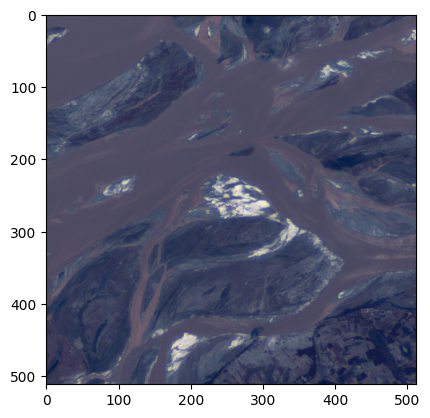

In [10]:
# Read the original image and get its bounds
input_path = "../samples/India_900498_S2Hand.tif"

with rasterio.open(input_path) as img_src:
    # Read RGB bands
    img_data = img_src.read([3, 2, 1])
    # Transpose to (height, width, channels) for matplotlib
    img_rgb = np.transpose(img_data, (1, 2, 0))
    # Normalize to 0-1 range for display
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())

plt.imshow(img_rgb)
plt.show()

### Send Inference Request to vLLM

Sends the image to the running server and saves the segmentation mask it returns as `mask.tiff`. This may take a few seconds the first time while the model warms up.

**You should see:** `Segmentation mask saved as mask.tiff`. If you instead see an error with a status code, the server is probably not running or is still starting — check its terminal. The `data` path in the cell must point to where the sample image actually lives on this machine; adjust it if you get a file-not-found error.

In [11]:
# Process remote image via URL
#payload = {
#    "data": {
#        "data": "https://huggingface.co/ibm-nasa-geospatial/Prithvi-EO-2.0-300M-TL-Sen1Floods11/resolve/main/examples/India_900498_S2Hand.tif",
#        "indices": [1, 2, 3, 8, 11, 12],
#        "data_format": "url",
#        "out_data_format": "b64_json",
#        "image_format": "tiff",
#    },
#    "model": "1_run_model_in_vllm",
#}

# Process path to local storage file
payload = {
    "data": {
        "data": "/home/sagemaker-user/ESA-NASA-Workshop-2026/Day 2/Track 3/Operational-GeoAI-Model-Serving/Part2/samples/India_900498_S2Hand.tif",
        "indices": [1, 2, 3, 8, 11, 12],
        "data_format": "path",
        "out_data_format": "b64_json",
        "image_format": "tiff",
    },
    "model": "1_run_model_in_vllm",
}

response = requests.post(
    "http://localhost:8000/pooling",
    headers={"Content-Type": "application/json"},
    data=json.dumps(payload),
)

if response.status_code == 200:
    result = response.json()
    mask_b64 = result["data"]["data"]
    mask_bytes = base64.b64decode(mask_b64)
    with open("mask.tiff", "wb") as f:
        f.write(mask_bytes)
    print("Segmentation mask saved as mask.tiff")
else:
    print(f"Error: Received status code {response.status_code}")
    print(f"Response: {response.text}")

Segmentation mask saved as mask.tiff


### Read the Mask

Opens the `mask.tiff` the server returned and displays it on its own. Each pixel value is a predicted class (here, flood vs. no flood).

**You should see:** a coloured mask image and a printout of its shape and the unique class values it contains.

Mask shape: (512, 512)
Unique mask values: [  0 255]


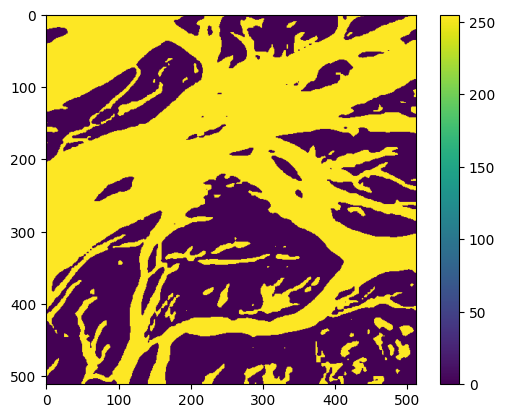

In [12]:
# Read the mask
with rasterio.open('mask.tiff') as mask_src:
    mask = mask_src.read(1)

print(f"Mask shape: {mask.shape}")
print(f"Unique mask values: {np.unique(mask)}")
plt.imshow(mask)
plt.colorbar()  # optional
plt.show()

### Overlay the Mask on the Original Image

Draws the predicted mask on top of the original image so you can judge whether the model found the right regions.

**You should see:** the satellite image with the predicted areas highlighted on top. If this looks reasonable, the model is being served correctly end to end.

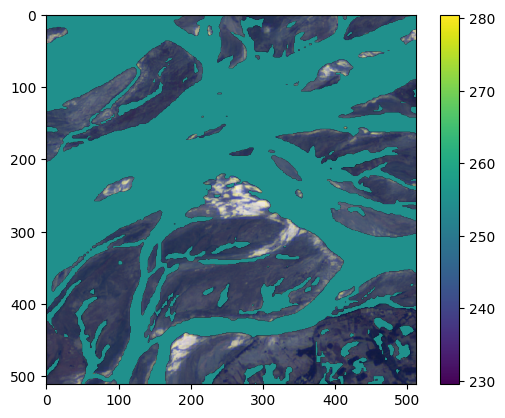

In [18]:
masked = np.ma.masked_where(mask == 0, mask)
plt.imshow(img_rgb)
plt.imshow(masked)
plt.colorbar()  # optional
           

## Done

If you saw the mask overlaid on the image, the vLLM server is working end to end. You can now move on to [Step 2: Benchmarking](../2_vllm_benchmarking/README.md). Leave the server terminal running if you want to continue.